# 01 · Refh quality and derived surfaces

This notebook examines the official CASALS L1B reference-height point for each pulse. The H5 `refh_longitude`, `refh_latitude`, and `refh` fields describe the geolocated receiver-waveform maximum. Height is kept as CASALS WGS84 ellipsoidal height. The waveform-derived noise labels, DSM, and tentative DTM below are derived products with separate meanings.

The primary quality sample is the 2024-11-12 granule (3,604,480 pulses). The DSM is from 2024-11-18 because that is the granule used for the current 2 m surface product. All maps use EPSG:32618 with metre axes. Product generation commands and exact input paths are explicit in the next cell.

## Paths and bounded display settings

The statistics use the full H5 arrays; map plots use a fixed seeded sample. The product files were generated by the current `casals` commands. If a local result is absent, the cell lists the exact command needed to recreate it.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import h5py
import laspy
import rasterio
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Run this notebook from the CASALS repository root.")
H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241112T165718_001_02.h5"
DSM_H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241118T171757_001_02.h5"
PRODUCT_ROOT = ROOT / "outputs/notebooks/01_refh_quality"
EXPORT_LAS = PRODUCT_ROOT / "export/point_clouds/casals_l1b_20241112T165718_001_02_levelA_refh_epsg32618.las"
FILTER_ROOT = PRODUCT_ROOT / "filter/point_clouds"
FILTER_STEM = "casals_l1b_20241112T165718_001_02"
RAW_LAS = FILTER_ROOT / f"{FILTER_STEM}_raw_refh_epsg32618.las"
NOISE_LAS = FILTER_ROOT / f"{FILTER_STEM}_noise_labeled_refh_epsg32618.las"
CLEAN_LAS = FILTER_ROOT / f"{FILTER_STEM}_clean_refh_epsg32618.las"
DSM_ROOT = PRODUCT_ROOT / "dsm"
DSM_PREFIX = "casals_l1b_20241118T171757_001_02_refh_surface"
DSM_STRICT = DSM_ROOT / f"{DSM_PREFIX}_dsm_strict_snr4p5_2m_epsg32618.tif"
DSM_FILLED = DSM_ROOT / f"{DSM_PREFIX}_dsm_snr4p5_2m_epsg32618.tif"
DSM_SUPPORT = DSM_ROOT / f"{DSM_PREFIX}_support_mask_snr4p5_2m_epsg32618.tif"
GROUND_ROOT = PRODUCT_ROOT / "ground"
GROUND_PREFIX = "casals_l1b_20241112T165718_001_02_tentative_ground_idw_filled_snr5_5m_epsg32618"
GROUND_DTM = GROUND_ROOT / f"{GROUND_PREFIX}.tif"
GROUND_SUPPORT = GROUND_ROOT / f"{GROUND_PREFIX}_support_mask.tif"
GROUND_SOURCE = GROUND_ROOT / f"{GROUND_PREFIX}_source_mask.tif"

required = [H5_PATH, DSM_H5_PATH, EXPORT_LAS, RAW_LAS, NOISE_LAS, CLEAN_LAS,
            DSM_STRICT, DSM_FILLED, DSM_SUPPORT, GROUND_DTM, GROUND_SUPPORT, GROUND_SOURCE]
missing = [path for path in required if not path.exists()]
if missing:
    commands = "\n".join([
        f"python -m casals_l1b refh export --h5 {H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/export --point-cloud-dir outputs/notebooks/01_refh_quality/export/point_clouds",
        f"python -m casals_l1b refh filter --h5 {H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/filter --point-cloud-dir outputs/notebooks/01_refh_quality/filter/point_clouds",
        f"python -m casals_l1b refh dsm --h5 {DSM_H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/dsm",
        f"python -m casals_l1b refh ground --h5 {H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/ground",
    ])
    raise FileNotFoundError("Missing explicit real-data products:\n" + "\n".join(map(str, missing)) + "\n\nGenerate them with:\n" + commands)

MAX_MAP_POINTS = 60_000
RNG_SEED = 42
print(f"H5: {H5_PATH.relative_to(ROOT)}")
print(f"DSM H5: {DSM_H5_PATH.relative_to(ROOT)}")
print(f"Map sample maximum: {MAX_MAP_POINTS:,} (seed={RNG_SEED})")

H5: data\raw\casals_l1b\casals_l1b_20241112T165718_001_02.h5
DSM H5: data\raw\casals_l1b\casals_l1b_20241118T171757_001_02.h5
Map sample maximum: 60,000 (seed=42)


## Full-record quality statistics

The H5 reader applies only finite, valid-coordinate checks here. `good_snr` is reported as its supplied quality flag; it is not equated with the filter’s noise class.

In [2]:
from casals_l1b.refh import read_refh_points, project_refh_points

points = read_refh_points(H5_PATH)
projected = project_refh_points(points)
summary = pd.DataFrame([
    {"measure": "input pulse records", "value": points.n_input_records, "unit": "pulses"},
    {"measure": "valid official refh records", "value": points.n_valid_records, "unit": "pulses"},
    {"measure": "good_snr = true", "value": int(points.good_snr.sum()), "unit": "pulses"},
    {"measure": "good_snr fraction", "value": float(points.good_snr.mean()), "unit": "fraction"},
    {"measure": "refh_snr >= 5", "value": int(np.count_nonzero(points.refh_snr >= 5.0)), "unit": "pulses"},
    {"measure": "refh_snr median", "value": float(np.median(points.refh_snr)), "unit": "dimensionless"},
    {"measure": "refh_amp median", "value": float(np.median(points.refh_amp)), "unit": "raw counts"},
    {"measure": "refh height median", "value": float(np.median(points.z_refh)), "unit": "m, WGS84 ellipsoidal"},
    {"measure": "horizontal CRS", "value": projected.utm_epsg, "unit": "EPSG"},
])
display(summary)
print("Projection round-trip maximum horizontal error (m):",
      projected.projection_check.get("approx_max_horizontal_error_m"))

,measure,value,unit
0,input pulse records,3.604480e+06,pulses
1,valid official refh records,3.604480e+06,pulses
2,good_snr = true,4.274000e+04,pulses
3,good_snr fraction,1.185747e-02,fraction
4,refh_snr >= 5,4.274000e+04,pulses
5,refh_snr median,1.997472e+00,dimensionless
6,refh_amp median,5.360000e+02,raw counts
7,refh height median,-2.550444e+01,"m, WGS84 ellipsoidal"
8,horizontal CRS,3.261800e+04,EPSG


Projection round-trip maximum horizontal error (m): 2.3729285203444306e-09


## Official refh footprint and signal distributions

The plotted points are a deterministic sample of the complete official refh footprint. Color limits use the 2nd and 98th percentiles to keep extreme returns from flattening the view.

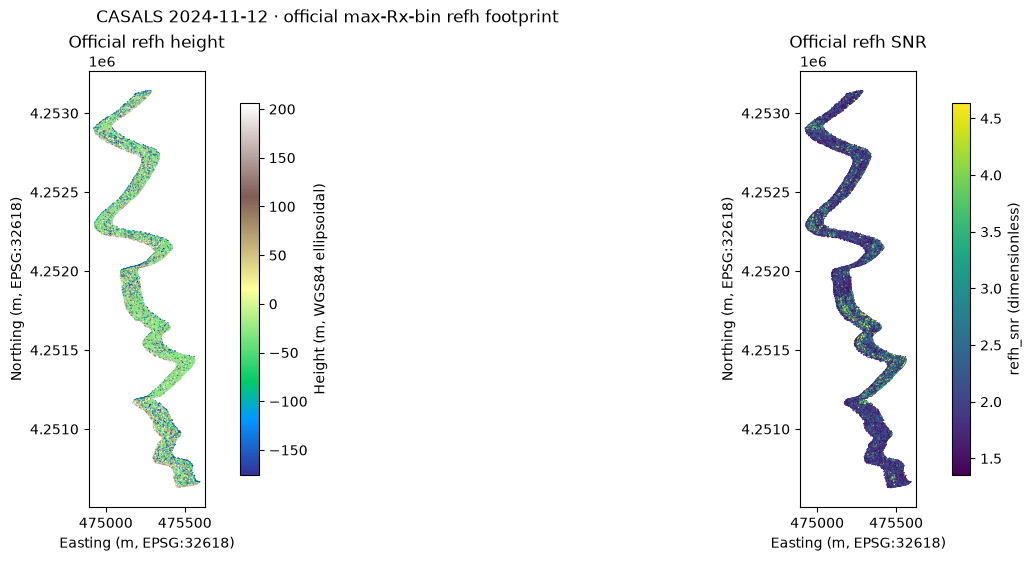

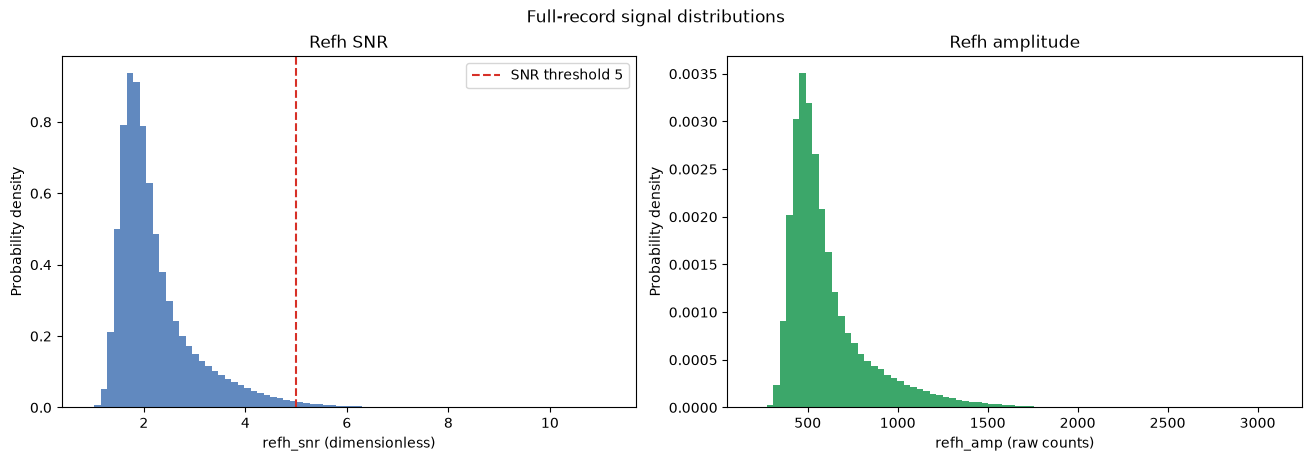

In [3]:
rng = np.random.default_rng(RNG_SEED)
plot_idx = rng.choice(points.n_valid_records, size=min(MAX_MAP_POINTS, points.n_valid_records), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
for ax, values, title, label, cmap in [
    (axes[0], points.z_refh, "Official refh height", "Height (m, WGS84 ellipsoidal)", "terrain"),
    (axes[1], points.refh_snr, "Official refh SNR", "refh_snr (dimensionless)", "viridis"),
]:
    lo, hi = np.nanpercentile(values, [2, 98])
    sc = ax.scatter(projected.easting[plot_idx], projected.northing[plot_idx],
                    c=values[plot_idx], s=1.0, cmap=cmap, vmin=lo, vmax=hi,
                    linewidths=0, rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("Easting (m, EPSG:32618)")
    ax.set_ylabel("Northing (m, EPSG:32618)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=ax, label=label, shrink=0.85)
fig.suptitle("CASALS 2024-11-12 · official max-Rx-bin refh footprint")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].hist(points.refh_snr, bins=80, density=True, color="#4575b4", alpha=0.85)
axes[0].axvline(5, color="#d73027", linestyle="--", label="SNR threshold 5")
axes[0].set(xlabel="refh_snr (dimensionless)", ylabel="Probability density", title="Refh SNR")
axes[0].legend()
axes[1].hist(points.refh_amp, bins=80, density=True, color="#1a9850", alpha=0.85)
axes[1].set(xlabel="refh_amp (raw counts)", ylabel="Probability density", title="Refh amplitude")
fig.suptitle("Full-record signal distributions")
plt.show()

## Raw, noise-labeled, and clean products

The refh filter first selects the supplied `good_snr` population, then applies its configured noise rules. Here all three products contain the same 42,740 points and the noise-labeled product has zero class-7 points. The evidence therefore shows quality selection with no additional noise removals for this granule and configuration.

,product,points,class 1,class 7,CRS
0,raw selected,42740,42740,0,32618
1,noise-labeled,42740,42740,0,32618
2,clean,42740,42740,0,32618


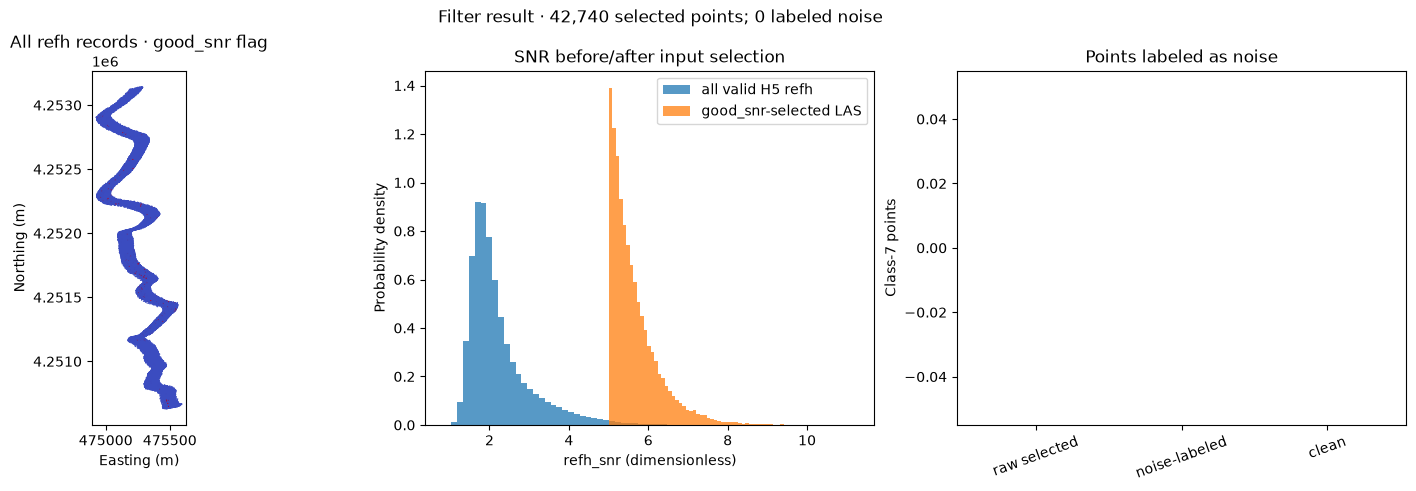

In [4]:
las_raw, las_noise, las_clean = (laspy.read(path) for path in (RAW_LAS, NOISE_LAS, CLEAN_LAS))
las_summary = []
for label, las in [("raw selected", las_raw), ("noise-labeled", las_noise), ("clean", las_clean)]:
    values, counts = np.unique(np.asarray(las.classification, dtype=np.uint8), return_counts=True)
    class_counts = {int(k): int(v) for k, v in zip(values, counts)}
    las_summary.append({"product": label, "points": int(las.header.point_count),
                        "class 1": class_counts.get(1, 0), "class 7": class_counts.get(7, 0),
                        "CRS": las.header.parse_crs().to_epsg()})
display(pd.DataFrame(las_summary))

all_keep = points.good_snr
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
axes[0].scatter(projected.easting[plot_idx], projected.northing[plot_idx],
                c=all_keep[plot_idx].astype(int), s=0.8, cmap="coolwarm", vmin=0, vmax=1,
                linewidths=0, rasterized=True)
axes[0].set(title="All refh records · good_snr flag", xlabel="Easting (m)", ylabel="Northing (m)")
axes[0].set_aspect("equal", adjustable="box")
axes[1].hist(points.refh_snr, bins=70, density=True, alpha=.75, label="all valid H5 refh")
axes[1].hist(np.asarray(las_raw.refh_snr), bins=70, density=True, alpha=.75, label="good_snr-selected LAS")
axes[1].set(title="SNR before/after input selection", xlabel="refh_snr (dimensionless)", ylabel="Probability density")
axes[1].legend()
labels = ["raw selected", "noise-labeled", "clean"]
noise_counts = [int(np.count_nonzero(np.asarray(l.classification) == 7)) for l in (las_raw, las_noise, las_clean)]
axes[2].bar(labels, noise_counts, color=["#777777", "#d73027", "#1a9850"])
axes[2].set(title="Points labeled as noise", ylabel="Class-7 points")
axes[2].tick_params(axis="x", rotation=20)
fig.suptitle("Filter result · 42,740 selected points; 0 labeled noise")
plt.show()

assert np.array_equal(las_raw.pulse_index, las_noise.pulse_index)
assert np.array_equal(las_raw.pulse_index, las_clean.pulse_index)

## Surface products: DSM and tentative DTM

The DSM is the selected refh surface at 2 m resolution, shown as strict observed cells, support-limited filled cells, and the support mask. The DTM is a different 5 m morphology and interpolation product from the 2024-11-12 granule. It is tentative and is not an official ground model. Raster heights retain a CASALS-derived ellipsoidal-height interpretation; no vertical datum conversion is applied.

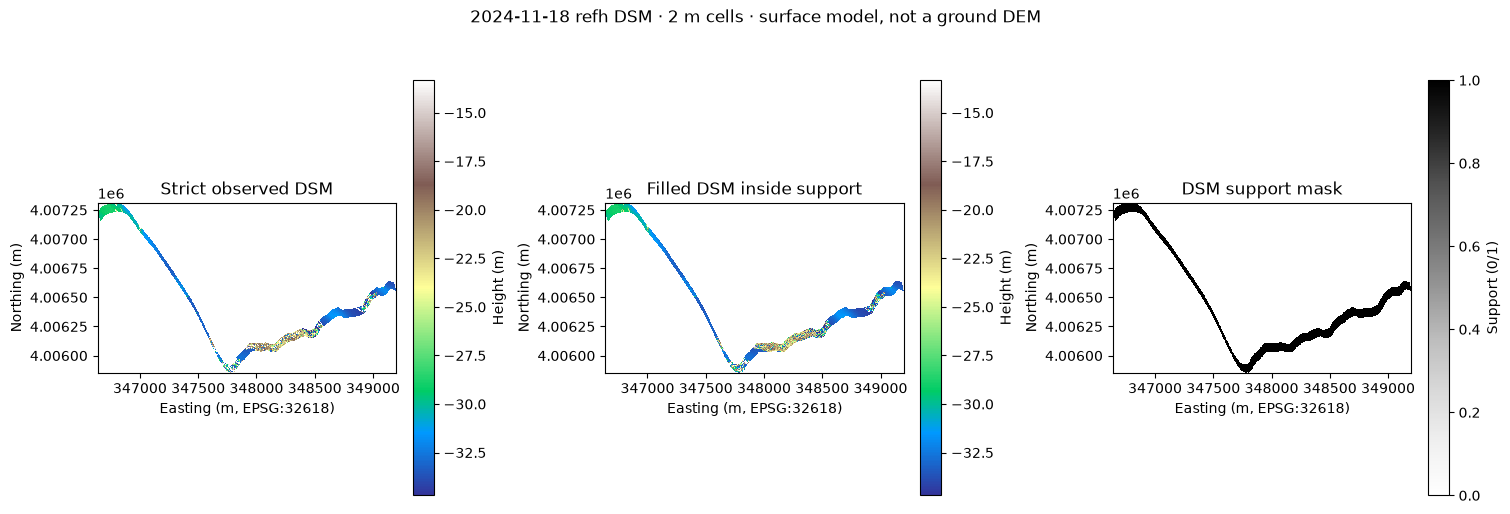

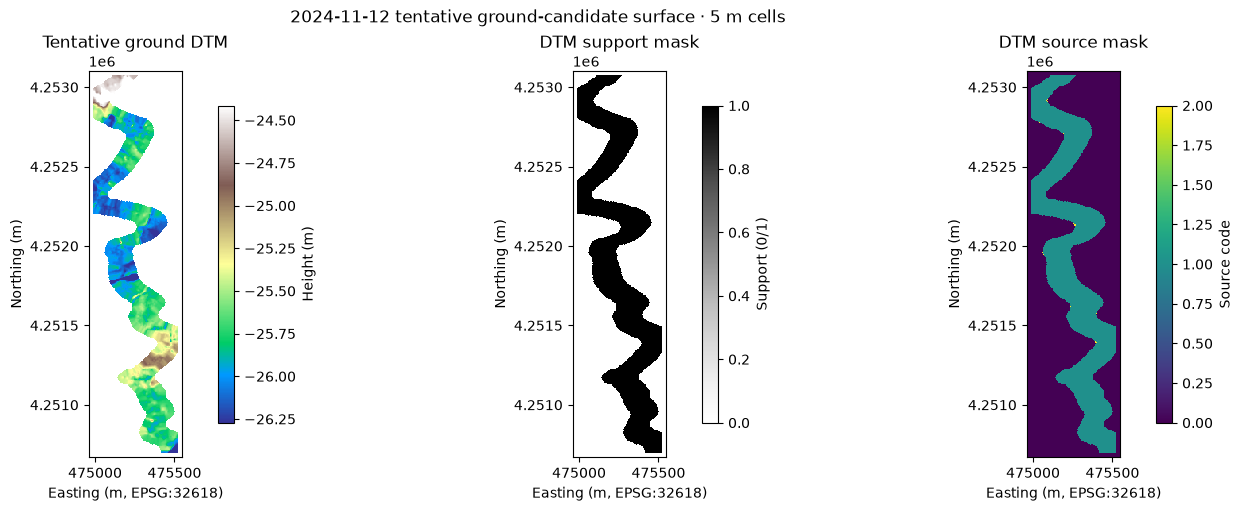

In [5]:
def raster_data(path):
    with rasterio.open(path) as ds:
        array = ds.read(1)
        return array, ds.bounds, ds.crs.to_string(), ds.nodata

strict, bounds, crs, strict_nodata = raster_data(DSM_STRICT)
filled, _, _, fill_nodata = raster_data(DSM_FILLED)
support, _, _, _ = raster_data(DSM_SUPPORT)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
strict_mask = np.ma.masked_equal(strict, strict_nodata)
filled_inside_support = np.ma.masked_where((support == 0) | (filled == fill_nodata), filled)
lo, hi = np.nanpercentile(filled[support > 0], [2, 98])
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4), constrained_layout=True)
for ax, arr, title, cmap in [
    (axes[0], strict_mask, "Strict observed DSM", "terrain"),
    (axes[1], filled_inside_support, "Filled DSM inside support", "terrain"),
    (axes[2], support, "DSM support mask", "Greys"),
]:
    is_mask = "mask" in title.lower()
    im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap,
                   vmin=None if is_mask else lo, vmax=None if is_mask else hi,
                   interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel(f"Easting (m, {crs})")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(im, ax=ax, label="Support (0/1)" if is_mask else "Height (m)", shrink=0.82)
fig.suptitle("2024-11-18 refh DSM · 2 m cells · surface model, not a ground DEM")
plt.show()

DTM, dtm_bounds, dtm_crs, dtm_nodata = raster_data(GROUND_DTM)
DTM_SUPPORT, _, _, _ = raster_data(GROUND_SUPPORT)
DTM_SOURCE, _, _, _ = raster_data(GROUND_SOURCE)
dtm_extent = [dtm_bounds.left, dtm_bounds.right, dtm_bounds.bottom, dtm_bounds.top]
dtm_masked = np.ma.masked_equal(DTM, dtm_nodata)
dtm_lo, dtm_hi = np.nanpercentile(DTM[DTM != dtm_nodata], [2, 98])
fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)
for ax, arr, title, cmap, lab in [
    (axes[0], dtm_masked, "Tentative ground DTM", "terrain", "Height (m)"),
    (axes[1], DTM_SUPPORT, "DTM support mask", "Greys", "Support (0/1)"),
    (axes[2], DTM_SOURCE, "DTM source mask", "viridis", "Source code"),
]:
    im = ax.imshow(arr, extent=dtm_extent, origin="upper", cmap=cmap,
                   vmin=dtm_lo if "mask" not in title else None,
                   vmax=dtm_hi if "mask" not in title else None,
                   interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel(f"Easting (m, {dtm_crs})")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(im, ax=ax, label=lab, shrink=0.82)
fig.suptitle("2024-11-12 tentative ground-candidate surface · 5 m cells")
plt.show()

## Interpretation and limits

- The official refh footprint is the CASALS max-Rx-bin georeference. It is not a discrete multi-return cloud.
- Only 1.19% of this granule carries `good_snr=True`; the filter’s selected 42,740 points were all retained and none were labeled as noise under the recorded thresholds.
- The DSM retains its strict observed-cell and support-limited fill distinction. The DTM is a tentative derived product with 18,508 valid cells in a 5 m grid; it is not a certified ground surface.
- All product elevations remain CASALS/refh-derived. The 3DEP comparison or a projected CRS does not convert ellipsoidal heights to an orthometric datum.